In [1]:
!pip -q install opencv-contrib-python-headless PyWavelets scikit-image scikit-learn pandas matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 8.3 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import time
import math
from pathlib import Path
from scipy import ndimage
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
from skimage.measure import shannon_entropy

from IPython.display import display

DRIVE_ROOT = Path('/content/drive/MyDrive')
DATASET_ROOT = DRIVE_ROOT / 'Feature_Extraction_Assignment_Image_Dataset'
OUTPUT_ROOT = DRIVE_ROOT / 'Feature_Extraction_Assignment_Output'

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

for i in range(1, 11):
    (OUTPUT_ROOT / f'{i:02d}_experiment').mkdir(parents=True, exist_ok=True)

print('Dataset:', DATASET_ROOT)
print('Output:', OUTPUT_ROOT)
print('Dataset exists:', DATASET_ROOT.exists())

Dataset: /content/drive/MyDrive/Feature_Extraction_Assignment_Image_Dataset
Output: /content/drive/MyDrive/Feature_Extraction_Assignment_Output
Dataset exists: True


In [5]:
files = []

for path in DATASET_ROOT.rglob('*'):
    if path.is_file():
        files.append(str(path.relative_to(DATASET_ROOT)))

for item in sorted(files):
    print(item)

01_base_feature_scene.png
02_edge_gaussian_noise.png
03_edge_salt_pepper_noise.png
04_texture_gabor_dwt.png
05_lines_corners_hough.png
06_orientation_shape.png
07_sift_reference.png
08_sift_transformed.png
09_surf_gloh_test.png
10_color_histogram.png
11_spectral_periodic.png
README.txt
similarity_gallery/gallery_circle_blue.png
similarity_gallery/gallery_circle_red_noisy.png
similarity_gallery/gallery_circle_red_small.png
similarity_gallery/gallery_square_red.png
similarity_gallery/gallery_triangle_red.png
similarity_gallery/query_circle_red.png


In [6]:
def find_file(name):
    matches = list(DATASET_ROOT.rglob(name))
    if not matches:
        raise FileNotFoundError(f'File not found: {name}')
    return matches[0]

def read_image(name, gray=False):
    path = find_file(name)
    flag = cv2.IMREAD_GRAYSCALE if gray else cv2.IMREAD_COLOR
    image = cv2.imread(str(path), flag)
    if image is None:
        raise ValueError(f'Unable to read: {path}')
    return image

def save_image(folder, name, image):
    path = OUTPUT_ROOT / folder / name
    cv2.imwrite(str(path), image)
    return path

def save_rgb_figure(folder, name, image, title=None, cmap=None):
    plt.figure(figsize=(8, 6))
    if len(image.shape) == 2:
        plt.imshow(image, cmap=cmap or 'gray')
    else:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    if title:
        plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / folder / name, dpi=200, bbox_inches='tight')
    plt.close()

def normalize_uint8(image):
    image = np.asarray(image, dtype=np.float32)
    mn = image.min()
    mx = image.max()
    if mx - mn < 1e-12:
        return np.zeros_like(image, dtype=np.uint8)
    return ((image - mn) * 255.0 / (mx - mn)).astype(np.uint8)

def resize_same(a, b):
    if a.shape[:2] != b.shape[:2]:
        b = cv2.resize(b, (a.shape[1], a.shape[0]))
    return b

print('Common functions loaded')

Common functions loaded


In [7]:
#Experiment 1 — Feature Extraction and Edge Detection

In [8]:
exp1 = '01_experiment'

image = read_image('01_base_feature_scene.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)

feature_image = cv2.drawKeypoints(
    image,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobel_x.astype(np.float32), sobel_y.astype(np.float32))
sobel = normalize_uint8(sobel)

prewitt_x_kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewitt_y_kernel = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

prewitt_x = cv2.filter2D(gray, cv2.CV_32F, prewitt_x_kernel)
prewitt_y = cv2.filter2D(gray, cv2.CV_32F, prewitt_y_kernel)
prewitt = cv2.magnitude(prewitt_x, prewitt_y)
prewitt = normalize_uint8(prewitt)

canny = cv2.Canny(gray, 100, 200)

save_image(exp1, '01_original.png', image)
save_image(exp1, '02_sobel_edges.png', sobel)
save_image(exp1, '03_prewitt_edges.png', prewitt)
save_image(exp1, '04_canny_edges.png', canny)
save_image(exp1, '05_sift_features.png', feature_image)

feature_data = pd.DataFrame({
    'Feature': ['SIFT keypoints', 'SIFT descriptor dimensions'],
    'Value': [len(keypoints), descriptors.shape[1] if descriptors is not None else 0]
})

feature_data.to_csv(OUTPUT_ROOT / exp1 / 'feature_extraction_results.csv', index=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original')

axes[0, 1].imshow(sobel, cmap='gray')
axes[0, 1].set_title('Sobel')

axes[0, 2].imshow(prewitt, cmap='gray')
axes[0, 2].set_title('Prewitt')

axes[1, 0].imshow(canny, cmap='gray')
axes[1, 0].set_title('Canny')

axes[1, 1].imshow(cv2.cvtColor(feature_image, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('SIFT Features')

axes[1, 2].axis('off')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / exp1 / 'edge_detection_comparison.png', dpi=200)
plt.close()

print('Experiment 1 completed')
print('SIFT keypoints:', len(keypoints))

Experiment 1 completed
SIFT keypoints: 184


In [9]:
#Experiment 2 — Edge Detection Performance Analysis

In [10]:
exp2 = '02_experiment'

clean = read_image('01_base_feature_scene.png', gray=True)

clean_sobel_x = cv2.Sobel(clean, cv2.CV_64F, 1, 0, ksize=3)
clean_sobel_y = cv2.Sobel(clean, cv2.CV_64F, 0, 1, ksize=3)
clean_sobel = normalize_uint8(cv2.magnitude(
    clean_sobel_x.astype(np.float32),
    clean_sobel_y.astype(np.float32)
))

clean_prewitt_x = cv2.filter2D(clean, cv2.CV_32F, prewitt_x_kernel)
clean_prewitt_y = cv2.filter2D(clean, cv2.CV_32F, prewitt_y_kernel)
clean_prewitt = normalize_uint8(cv2.magnitude(clean_prewitt_x, clean_prewitt_y))

clean_canny = cv2.Canny(clean, 100, 200)

reference = {
    'Sobel': clean_sobel > 60,
    'Prewitt': clean_prewitt > 60,
    'Canny': clean_canny > 0
}

gaussian = read_image('02_edge_gaussian_noise.png', gray=True)
salt_pepper = read_image('03_edge_salt_pepper_noise.png', gray=True)

noise_images = {
    'Gaussian': gaussian,
    'Salt_Pepper': salt_pepper
}

def detect_edges(image, method):
    start = time.perf_counter()

    if method == 'Sobel':
        gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
        edges = normalize_uint8(cv2.magnitude(
            gx.astype(np.float32),
            gy.astype(np.float32)
        ))
        edges = edges > 60

    elif method == 'Prewitt':
        gx = cv2.filter2D(image, cv2.CV_32F, prewitt_x_kernel)
        gy = cv2.filter2D(image, cv2.CV_32F, prewitt_y_kernel)
        edges = normalize_uint8(cv2.magnitude(gx, gy))
        edges = edges > 60

    else:
        edges = cv2.Canny(image, 100, 200) > 0

    elapsed = time.perf_counter() - start

    return edges, elapsed

def performance_metrics(detected, reference_edge):
    reference_dilated = cv2.dilate(
        reference_edge.astype(np.uint8),
        np.ones((3, 3), np.uint8)
    ).astype(bool)

    detected_count = detected.sum()
    matched = np.logical_and(detected, reference_dilated).sum()
    continuity = matched / max(reference_edge.sum(), 1)
    false_edges = np.logical_and(detected, ~reference_dilated).sum()
    false_edge_rate = false_edges / max(detected_count, 1)

    return continuity, false_edge_rate

records = []

for noise_name, noisy_image in noise_images.items():
    save_image(exp2, f'{noise_name.lower()}_input.png', noisy_image)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(noisy_image, cmap='gray')
    axes[0].set_title(noise_name)

    for index, method in enumerate(['Sobel', 'Prewitt', 'Canny'], start=1):
        detected, elapsed = detect_edges(noisy_image, method)
        continuity, false_rate = performance_metrics(
            detected,
            reference[method]
        )

        records.append({
            'Noise': noise_name,
            'Method': method,
            'Edge_Continuity': continuity,
            'False_Edge_Rate': false_rate,
            'Processing_Time_Seconds': elapsed
        })

        axes[index].imshow(detected, cmap='gray')
        axes[index].set_title(method)

        save_image(
            exp2,
            f'{noise_name.lower()}_{method.lower()}_edges.png',
            (detected.astype(np.uint8) * 255)
        )

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(
        OUTPUT_ROOT / exp2 / f'{noise_name.lower()}_comparison.png',
        dpi=200
    )
    plt.close()

performance_df = pd.DataFrame(records)
performance_df.to_csv(
    OUTPUT_ROOT / exp2 / 'edge_detection_performance.csv',
    index=False
)

display(performance_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for noise in performance_df['Noise'].unique():
    subset = performance_df[performance_df['Noise'] == noise]
    axes[0].plot(
        subset['Method'],
        subset['Edge_Continuity'],
        marker='o',
        label=noise
    )
    axes[1].plot(
        subset['Method'],
        subset['False_Edge_Rate'],
        marker='o',
        label=noise
    )
    axes[2].plot(
        subset['Method'],
        subset['Processing_Time_Seconds'],
        marker='o',
        label=noise
    )

axes[0].set_title('Edge Continuity')
axes[1].set_title('False Edge Rate')
axes[2].set_title('Processing Time')

for ax in axes:
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig(
    OUTPUT_ROOT / exp2 / 'performance_analysis.png',
    dpi=200
)
plt.close()

print('Experiment 2 completed')

,Noise,Method,Edge_Continuity,False_Edge_Rate,Processing_Time_Seconds
0,Gaussian,Sobel,0.920788,0.026305,0.013607
1,Gaussian,Prewitt,0.939181,0.026258,0.006291
2,Gaussian,Canny,1.111405,0.960318,0.008269
3,Salt_Pepper,Sobel,1.083504,0.864433,0.008848
4,Salt_Pepper,Prewitt,1.088363,0.857490,0.007644
5,Salt_Pepper,Canny,1.097287,0.933451,0.004962


Experiment 2 completed


In [11]:
#Experiment 3 — Gabor Filter and Texture Feature Extraction

In [12]:
exp3 = '03_experiment'

image = read_image('04_texture_gabor_dwt.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gray_float = gray.astype(np.float32) / 255.0

orientations = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
frequencies = [0.08, 0.16, 0.32]

texture_records = []
response_images = []

for theta in orientations:
    for frequency in frequencies:
        kernel = cv2.getGaborKernel(
            (31, 31),
            4.0,
            theta,
            1.0 / frequency,
            0.5,
            0,
            ktype=cv2.CV_32F
        )

        response = cv2.filter2D(gray_float, cv2.CV_32F, kernel)
        response_norm = normalize_uint8(np.abs(response))
        response_images.append((theta, frequency, response_norm))

        h, w = response.shape
        regions = {
            'Top_Left': response[:h//2, :w//2],
            'Top_Right': response[:h//2, w//2:],
            'Bottom_Left': response[h//2:, :w//2],
            'Bottom_Right': response[h//2:, w//2:]
        }

        for region_name, region in regions.items():
            texture_records.append({
                'Orientation_Degrees': np.degrees(theta),
                'Frequency': frequency,
                'Region': region_name,
                'Mean': float(np.mean(region)),
                'Standard_Deviation': float(np.std(region)),
                'Energy': float(np.mean(region ** 2)),
                'Entropy': float(shannon_entropy(normalize_uint8(region)))
            })

texture_df = pd.DataFrame(texture_records)

texture_df.to_csv(
    OUTPUT_ROOT / exp3 / 'gabor_texture_features.csv',
    index=False
)

fig, axes = plt.subplots(
    len(orientations),
    len(frequencies),
    figsize=(12, 12)
)

for index, (theta, frequency, response) in enumerate(response_images):
    row = index // len(frequencies)
    col = index % len(frequencies)
    axes[row, col].imshow(response, cmap='gray')
    axes[row, col].set_title(
        f'{np.degrees(theta):.0f}° | f={frequency}'
    )
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig(
    OUTPUT_ROOT / exp3 / 'gabor_filter_comparison.png',
    dpi=200
)
plt.close()

for theta, frequency, response in response_images:
    name = f'gabor_{int(np.degrees(theta))}deg_{str(frequency).replace(".", "_")}.png'
    save_image(exp3, name, response)

region_summary = texture_df.groupby('Region')[
    ['Mean', 'Standard_Deviation', 'Energy', 'Entropy']
].mean().reset_index()

region_summary.to_csv(
    OUTPUT_ROOT / exp3 / 'texture_region_comparison.csv',
    index=False
)

display(region_summary)

print('Experiment 3 completed')

,Region,Mean,Standard_Deviation,Energy,Entropy
0,Bottom_Left,4.452556,3.421795,87.111058,4.998586
1,Bottom_Right,4.469016,2.452894,73.483201,5.137042
2,Top_Left,4.452556,3.421795,87.111062,4.998586
3,Top_Right,4.468579,2.467097,73.547887,5.165461


Experiment 3 completed


In [13]:
#Experiment 4 — 2-D Discrete Wavelet Transform

In [14]:
exp4 = '04_experiment'

image = read_image('04_texture_gabor_dwt.png', gray=True)

coeffs = pywt.dwt2(image, 'haar')
approximation, (horizontal, vertical, diagonal) = coeffs

approximation_img = normalize_uint8(approximation)
horizontal_img = normalize_uint8(np.abs(horizontal))
vertical_img = normalize_uint8(np.abs(vertical))
diagonal_img = normalize_uint8(np.abs(diagonal))

reconstructed = pywt.idwt2(coeffs, 'haar')
reconstructed = np.clip(reconstructed, 0, 255).astype(np.uint8)

save_image(exp4, '01_original.png', image)
save_image(exp4, '02_approximation.png', approximation_img)
save_image(exp4, '03_horizontal_detail.png', horizontal_img)
save_image(exp4, '04_vertical_detail.png', vertical_img)
save_image(exp4, '05_diagonal_detail.png', diagonal_img)
save_image(exp4, '06_reconstructed.png', reconstructed)

mse = np.mean(
    (image.astype(np.float32) - reconstructed.astype(np.float32)) ** 2
)

mae = np.mean(
    np.abs(image.astype(np.float32) - reconstructed.astype(np.float32))
)

dwt_results = pd.DataFrame({
    'Measure': ['MSE', 'MAE'],
    'Value': [mse, mae]
})

dwt_results.to_csv(
    OUTPUT_ROOT / exp4 / 'dwt_reconstruction_metrics.csv',
    index=False
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

images = [
    image,
    approximation_img,
    horizontal_img,
    vertical_img,
    diagonal_img,
    reconstructed
]

titles = [
    'Original',
    'Approximation',
    'Horizontal Detail',
    'Vertical Detail',
    'Diagonal Detail',
    'Reconstructed'
]

for ax, img, title in zip(axes.flat, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig(
    OUTPUT_ROOT / exp4 / 'dwt_decomposition_reconstruction.png',
    dpi=200
)
plt.close()

print('Experiment 4 completed')
print('Reconstruction MSE:', mse)
print('Reconstruction MAE:', mae)

Experiment 4 completed
Reconstruction MSE: 1.8518518e-06
Reconstruction MAE: 1.8518518e-06


In [15]:
#Experiment 5 — Line, Corner and Hough Transform Detection

In [17]:
exp5 = '05_experiment'

image = read_image('05_lines_corners_hough.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=50,
    minLineLength=40,
    maxLineGap=10
)

line_image = image.copy()
line_count = 0

if lines is not None:
    lines = np.asarray(lines).reshape(-1, 4)

    for x1, y1, x2, y2 in lines:
        cv2.line(
            line_image,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (0, 255, 0),
            2
        )
        line_count += 1

corner_image = image.copy()

gray_float = np.float32(gray)

harris = cv2.cornerHarris(
    gray_float,
    2,
    3,
    0.04
)

harris = cv2.dilate(harris, None)

threshold = 0.01 * harris.max()
corner_mask = harris > threshold
corner_image[corner_mask] = [0, 0, 255]

corner_count = int(np.sum(corner_mask))

circle_image = image.copy()

circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=20,
    param1=100,
    param2=30,
    minRadius=5,
    maxRadius=0
)

circle_count = 0

if circles is not None:
    circles = np.round(circles[0]).astype(int)

    for x, y, r in circles:
        cv2.circle(
            circle_image,
            (int(x), int(y)),
            int(r),
            (255, 0, 0),
            2
        )
        cv2.circle(
            circle_image,
            (int(x), int(y)),
            2,
            (0, 255, 0),
            3
        )
        circle_count += 1

save_image(exp5, '01_original.png', image)
save_image(exp5, '02_canny_edges.png', edges)
save_image(exp5, '03_hough_lines.png', line_image)
save_image(exp5, '04_harris_corners.png', corner_image)
save_image(exp5, '05_hough_circles.png', circle_image)

results = pd.DataFrame({
    'Feature': [
        'Hough Lines',
        'Harris Corners',
        'Hough Circles'
    ],
    'Count': [
        line_count,
        corner_count,
        circle_count
    ]
})

results.to_csv(
    OUTPUT_ROOT / exp5 / 'detected_feature_counts.csv',
    index=False
)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

images = [
    image,
    edges,
    line_image,
    corner_image,
    circle_image,
    np.zeros_like(gray)
]

titles = [
    'Original',
    'Canny Edges',
    'Hough Lines',
    'Harris Corners',
    'Hough Circles',
    ''
]

for ax, img, title in zip(axes.flat, images, titles):
    if len(img.shape) == 2:
        ax.imshow(img, cmap='gray')
    else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()

plt.savefig(
    OUTPUT_ROOT / exp5 / 'line_corner_hough_comparison.png',
    dpi=200
)

plt.close()

display(results)

print('Experiment 5 completed')

,Feature,Count
0,Hough Lines,32
1,Harris Corners,12826
2,Hough Circles,11


Experiment 5 completed


In [18]:
#Experiment 6 — Orientation Histogram and Shape Features

In [19]:
exp6 = '06_experiment'

image = read_image('06_orientation_shape.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

magnitude = cv2.magnitude(gx, gy)
orientation = cv2.phase(gx, gy, angleInDegrees=True)

histogram, bin_edges = np.histogram(
    orientation,
    bins=18,
    range=(0, 360),
    weights=magnitude
)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(10, 6))
plt.bar(bin_centers, histogram, width=18)
plt.xlabel('Orientation (degrees)')
plt.ylabel('Weighted Gradient Magnitude')
plt.title('Orientation Histogram')
plt.xticks(np.arange(0, 361, 45))
plt.tight_layout()
plt.savefig(
    OUTPUT_ROOT / exp6 / 'orientation_histogram.png',
    dpi=200
)
plt.close()

magnitude_img = normalize_uint8(magnitude)

orientation_img = ((orientation / 360.0) * 255).astype(np.uint8)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

shape_image = image.copy()
shape_records = []

for index, contour in enumerate(contours):
    area = cv2.contourArea(contour)

    if area < 20:
        continue

    perimeter = cv2.arcLength(contour, True)
    x, y, w, h = cv2.boundingRect(contour)
    moments = cv2.moments(contour)

    if moments['m00'] != 0:
        cx = moments['m10'] / moments['m00']
        cy = moments['m01'] / moments['m00']
    else:
        cx = 0
        cy = 0

    aspect_ratio = w / h if h != 0 else 0
    circularity = (
        4 * np.pi * area / (perimeter ** 2)
        if perimeter != 0 else 0
    )

    shape_records.append({
        'Object': index + 1,
        'Area': area,
        'Perimeter': perimeter,
        'Centroid_X': cx,
        'Centroid_Y': cy,
        'Aspect_Ratio': aspect_ratio,
        'Circularity': circularity
    })

    cv2.drawContours(
        shape_image,
        [contour],
        -1,
        (0, 255, 0),
        2
    )

    cv2.circle(
        shape_image,
        (int(cx), int(cy)),
        4,
        (0, 0, 255),
        -1
    )

    cv2.putText(
        shape_image,
        str(index + 1),
        (int(cx), int(cy)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

shape_df = pd.DataFrame(shape_records)

save_image(exp6, '01_original.png', image)
save_image(exp6, '02_gradient_magnitude.png', magnitude_img)
save_image(exp6, '03_gradient_orientation.png', orientation_img)
save_image(exp6, '04_binary_objects.png', binary)
save_image(exp6, '05_shape_features.png', shape_image)

pd.DataFrame({
    'Bin_Center_Degrees': bin_centers,
    'Weighted_Gradient_Magnitude': histogram
}).to_csv(
    OUTPUT_ROOT / exp6 / 'orientation_histogram_values.csv',
    index=False
)

shape_df.to_csv(
    OUTPUT_ROOT / exp6 / 'shape_features.csv',
    index=False
)

display(shape_df)

print('Experiment 6 completed')

,Object,Area,Perimeter,Centroid_X,Centroid_Y,Aspect_Ratio,Circularity
0,1,538501.0,2996.0,449.5,299.5,1.5,0.753898


Experiment 6 completed


In [20]:
#Experiment 7 — Local Feature Extraction Using SIFT

In [21]:
exp7 = '07_experiment'

reference = read_image('07_sift_reference.png')
transformed = read_image('08_sift_transformed.png')

reference_gray = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)
transformed_gray = cv2.cvtColor(transformed, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(reference_gray, None)
kp2, des2 = sift.detectAndCompute(transformed_gray, None)

bf = cv2.BFMatcher(cv2.NORM_L2)

matches = bf.knnMatch(des1, des2, k=2)

good_matches = []

for pair in matches:
    if len(pair) == 2:
        m, n = pair
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

good_matches = sorted(
    good_matches,
    key=lambda x: x.distance
)

best_matches = good_matches[:50]

match_image = cv2.drawMatches(
    reference,
    kp1,
    transformed,
    kp2,
    best_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

reference_keypoints = cv2.drawKeypoints(
    reference,
    kp1,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

transformed_keypoints = cv2.drawKeypoints(
    transformed,
    kp2,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

save_image(exp7, '01_reference.png', reference)
save_image(exp7, '02_transformed.png', transformed)
save_image(exp7, '03_reference_keypoints.png', reference_keypoints)
save_image(exp7, '04_transformed_keypoints.png', transformed_keypoints)
save_image(exp7, '05_best_sift_matches.png', match_image)

sift_results = pd.DataFrame({
    'Measure': [
        'Reference Keypoints',
        'Transformed Keypoints',
        'Total KNN Matches',
        'Good Matches',
        'Displayed Best Matches',
        'Descriptor Size'
    ],
    'Value': [
        len(kp1),
        len(kp2),
        len(matches),
        len(good_matches),
        len(best_matches),
        des1.shape[1] if des1 is not None else 0
    ]
})

sift_results.to_csv(
    OUTPUT_ROOT / exp7 / 'sift_matching_results.csv',
    index=False
)

display(sift_results)

print('Experiment 7 completed')

,Measure,Value
0,Reference Keypoints,176
1,Transformed Keypoints,271
2,Total KNN Matches,176
3,Good Matches,35
4,Displayed Best Matches,35
5,Descriptor Size,128


Experiment 7 completed


In [22]:
#Experiment 8 — SIFT, SURF and GLOH Feature Analysis

In [23]:
exp8 = '08_experiment'

image = read_image('09_surf_gloh_test.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

scale_matrix = cv2.getRotationMatrix2D(
    (image.shape[1] / 2, image.shape[0] / 2),
    18,
    1.15
)

transformed = cv2.warpAffine(
    image,
    scale_matrix,
    (image.shape[1], image.shape[0])
)

transformed_gray = cv2.cvtColor(transformed, cv2.COLOR_BGR2GRAY)

save_image(exp8, '01_original.png', image)
save_image(exp8, '02_transformed.png', transformed)

def ratio_matches(des1, des2, norm_type):
    if des1 is None or des2 is None:
        return []

    matcher = cv2.BFMatcher(norm_type)
    raw = matcher.knnMatch(des1, des2, k=2)

    good = []

    for pair in raw:
        if len(pair) == 2:
            m, n = pair
            if m.distance < 0.75 * n.distance:
                good.append(m)

    return sorted(good, key=lambda x: x.distance)

sift = cv2.SIFT_create()

sift_kp1, sift_des1 = sift.detectAndCompute(gray, None)
sift_kp2, sift_des2 = sift.detectAndCompute(transformed_gray, None)

sift_matches = ratio_matches(
    sift_des1,
    sift_des2,
    cv2.NORM_L2
)

sift_display = cv2.drawMatches(
    image,
    sift_kp1,
    transformed,
    sift_kp2,
    sift_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

save_image(exp8, '03_sift_matches.png', sift_display)

surf_available = False
surf_kp1 = []
surf_kp2 = []
surf_des1 = None
surf_des2 = None
surf_matches = []

try:
    surf = cv2.xfeatures2d.SURF_create(400)
    surf_available = True
    surf_kp1, surf_des1 = surf.detectAndCompute(gray, None)
    surf_kp2, surf_des2 = surf.detectAndCompute(transformed_gray, None)
    surf_matches = ratio_matches(
        surf_des1,
        surf_des2,
        cv2.NORM_L2
    )
except Exception:
    surf_available = False

if surf_available:
    surf_display = cv2.drawMatches(
        image,
        surf_kp1,
        transformed,
        surf_kp2,
        surf_matches[:50],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )
    save_image(exp8, '04_surf_matches.png', surf_display)

def gloh_descriptor(gray_image, keypoint, patch_size=41):
    half = patch_size // 2
    x = int(round(keypoint.pt[0]))
    y = int(round(keypoint.pt[1]))

    padded = cv2.copyMakeBorder(
        gray_image,
        half,
        half,
        half,
        half,
        cv2.BORDER_REFLECT101
    )

    px = x + half
    py = y + half

    patch = padded[
        py-half:py+half+1,
        px-half:px+half+1
    ]

    gx = cv2.Sobel(
        patch,
        cv2.CV_32F,
        1,
        0,
        ksize=3
    )

    gy = cv2.Sobel(
        patch,
        cv2.CV_32F,
        0,
        1,
        ksize=3
    )

    magnitude = cv2.magnitude(gx, gy)
    angle = cv2.phase(gx, gy, angleInDegrees=False)

    yy, xx = np.mgrid[
        -half:half+1,
        -half:half+1
    ]

    radius = np.sqrt(xx ** 2 + yy ** 2)
    theta = np.arctan2(yy, xx)

    bins = np.full(radius.shape, -1, dtype=np.int32)

    bins[radius <= 4] = 0

    ring1 = (radius > 4) & (radius <= 10)
    ring2 = (radius > 10) & (radius <= 20)

    sector1 = ((theta + np.pi) / (2 * np.pi) * 8).astype(int) % 8
    sector2 = ((theta + np.pi) / (2 * np.pi) * 8).astype(int) % 8

    bins[ring1] = 1 + sector1[ring1]
    bins[ring2] = 9 + sector2[ring2]

    descriptor = []

    for spatial_bin in range(17):
        mask = bins == spatial_bin

        if np.any(mask):
            hist, _ = np.histogram(
                angle[mask],
                bins=16,
                range=(0, 2 * np.pi),
                weights=magnitude[mask]
            )
        else:
            hist = np.zeros(16)

        descriptor.extend(hist)

    descriptor = np.asarray(descriptor, dtype=np.float32)

    norm = np.linalg.norm(descriptor)

    if norm > 1e-12:
        descriptor /= norm

    return descriptor

gloh_kp1 = sift_kp1[:300]
gloh_kp2 = sift_kp2[:300]

gloh_des1 = np.array([
    gloh_descriptor(gray, kp)
    for kp in gloh_kp1
])

gloh_des2 = np.array([
    gloh_descriptor(transformed_gray, kp)
    for kp in gloh_kp2
])

gloh_matches = ratio_matches(
    gloh_des1,
    gloh_des2,
    cv2.NORM_L2
)

gloh_display = cv2.drawMatches(
    image,
    gloh_kp1,
    transformed,
    gloh_kp2,
    gloh_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

save_image(exp8, '05_gloh_matches.png', gloh_display)

comparison = pd.DataFrame([
    {
        'Method': 'SIFT',
        'Keypoints_Image_1': len(sift_kp1),
        'Keypoints_Image_2': len(sift_kp2),
        'Descriptor_Size': sift_des1.shape[1] if sift_des1 is not None else 0,
        'Good_Matches': len(sift_matches),
        'Available': True
    },
    {
        'Method': 'SURF',
        'Keypoints_Image_1': len(surf_kp1),
        'Keypoints_Image_2': len(surf_kp2),
        'Descriptor_Size': surf_des1.shape[1] if surf_des1 is not None else 0,
        'Good_Matches': len(surf_matches),
        'Available': surf_available
    },
    {
        'Method': 'GLOH',
        'Keypoints_Image_1': len(gloh_kp1),
        'Keypoints_Image_2': len(gloh_kp2),
        'Descriptor_Size': gloh_des1.shape[1],
        'Good_Matches': len(gloh_matches),
        'Available': True
    }
])

comparison.to_csv(
    OUTPUT_ROOT / exp8 / 'sift_surf_gloh_comparison.csv',
    index=False
)

display(comparison)

print('Experiment 8 completed')

,Method,Keypoints_Image_1,Keypoints_Image_2,Descriptor_Size,Good_Matches,Available
0,SIFT,294,360,128,40,True
1,SURF,0,0,0,0,False
2,GLOH,294,300,272,14,True


Experiment 8 completed


In [24]:
#Experiment 9 — Histogram, Color, Spectral and Texture Features

In [25]:
exp9 = '09_experiment'

image = read_image('10_color_histogram.png')

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

gray_hist = cv2.calcHist(
    [gray],
    [0],
    None,
    [32],
    [0, 256]
).flatten()

gray_hist = gray_hist / max(gray_hist.sum(), 1)

color_features = []

for channel in range(3):
    hist = cv2.calcHist(
        [hsv],
        [channel],
        None,
        [16],
        [0, 256] if channel != 0 else [0, 180]
    ).flatten()

    hist = hist / max(hist.sum(), 1)
    color_features.extend(hist)

f = np.fft.fft2(gray.astype(np.float32))
fshift = np.fft.fftshift(f)
magnitude_spectrum = np.log1p(np.abs(fshift))

h, w = magnitude_spectrum.shape
cy = h // 2
cx = w // 2

yy, xx = np.indices((h, w))
radius = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)

max_radius = int(min(h, w) / 2)

spectral_features = []

for r1, r2 in zip(
    np.linspace(0, max_radius, 17)[:-1],
    np.linspace(0, max_radius, 17)[1:]
):
    mask = (radius >= r1) & (radius < r2)

    if np.any(mask):
        spectral_features.append(
            float(np.mean(magnitude_spectrum[mask]))
        )
    else:
        spectral_features.append(0.0)

lbp = local_binary_pattern(
    gray,
    8,
    1,
    method='uniform'
)

lbp_hist, _ = np.histogram(
    lbp.ravel(),
    bins=np.arange(0, 11),
    range=(0, 10)
)

lbp_hist = lbp_hist.astype(np.float32)
lbp_hist = lbp_hist / max(lbp_hist.sum(), 1)

gabor_features = []

for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
    kernel = cv2.getGaborKernel(
        (31, 31),
        4,
        theta,
        10,
        0.5,
        0,
        ktype=cv2.CV_32F
    )

    response = cv2.filter2D(
        gray.astype(np.float32) / 255,
        cv2.CV_32F,
        kernel
    )

    gabor_features.extend([
        float(np.mean(response)),
        float(np.std(response)),
        float(np.mean(response ** 2))
    ])

combined_features = np.concatenate([
    gray_hist,
    np.asarray(color_features),
    np.asarray(spectral_features),
    lbp_hist,
    np.asarray(gabor_features)
])

feature_names = []

feature_names.extend([
    f'Gray_Hist_{i}'
    for i in range(len(gray_hist))
])

feature_names.extend([
    f'Color_Hist_{i}'
    for i in range(len(color_features))
])

feature_names.extend([
    f'Spectral_{i}'
    for i in range(len(spectral_features))
])

feature_names.extend([
    f'LBP_{i}'
    for i in range(len(lbp_hist))
])

feature_names.extend([
    f'Gabor_{i}'
    for i in range(len(gabor_features))
])

feature_vector_df = pd.DataFrame(
    [combined_features],
    columns=feature_names
)

feature_vector_df.to_csv(
    OUTPUT_ROOT / exp9 / 'combined_feature_vector.csv',
    index=False
)

np.save(
    OUTPUT_ROOT / exp9 / 'combined_feature_vector.npy',
    combined_features
)

save_image(
    exp9,
    '01_grayscale.png',
    gray
)

save_image(
    exp9,
    '02_fourier_spectrum.png',
    normalize_uint8(magnitude_spectrum)
)

plt.figure(figsize=(10, 5))
plt.plot(gray_hist)
plt.title('Grayscale Histogram')
plt.xlabel('Bin')
plt.ylabel('Normalized Frequency')
plt.tight_layout()
plt.savefig(
    OUTPUT_ROOT / exp9 / '03_grayscale_histogram.png',
    dpi=200
)
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(spectral_features)
plt.title('Spectral Features')
plt.xlabel('Radial Frequency Bin')
plt.ylabel('Mean Spectrum')
plt.tight_layout()
plt.savefig(
    OUTPUT_ROOT / exp9 / '04_spectral_features.png',
    dpi=200
)
plt.close()

plt.figure(figsize=(10, 5))
plt.bar(range(len(lbp_hist)), lbp_hist)
plt.title('LBP Texture Histogram')
plt.xlabel('LBP Bin')
plt.ylabel('Normalized Frequency')
plt.tight_layout()
plt.savefig(
    OUTPUT_ROOT / exp9 / '05_lbp_histogram.png',
    dpi=200
)
plt.close()

summary = pd.DataFrame({
    'Feature_Type': [
        'Grayscale Histogram',
        'Color Histogram',
        'Spectral/Fourier',
        'LBP Texture',
        'Gabor Texture',
        'Combined Feature Vector'
    ],
    'Feature_Count': [
        len(gray_hist),
        len(color_features),
        len(spectral_features),
        len(lbp_hist),
        len(gabor_features),
        len(combined_features)
    ]
})

summary.to_csv(
    OUTPUT_ROOT / exp9 / 'feature_dimension_summary.csv',
    index=False
)

display(summary)

print('Experiment 9 completed')
print('Combined feature vector size:', len(combined_features))

,Feature_Type,Feature_Count
0,Grayscale Histogram,32
1,Color Histogram,48
2,Spectral/Fourier,16
3,LBP Texture,10
4,Gabor Texture,12
5,Combined Feature Vector,118


Experiment 9 completed
Combined feature vector size: 118


In [26]:
#Experiment 10 — Feature Vector Analysis and Similarity Measures

Query: /content/drive/MyDrive/Feature_Extraction_Assignment_Image_Dataset/similarity_gallery/query_circle_red.png
Gallery images:
gallery_circle_blue.png
gallery_circle_red_noisy.png
gallery_circle_red_small.png
gallery_square_red.png
gallery_triangle_red.png


,Image,Euclidean_Distance,Manhattan_Distance,Cosine_Similarity,Correlation,Euclidean_Rank,Manhattan_Rank,Cosine_Rank,Correlation_Rank,Average_Rank,Overall_Rank
0,gallery_circle_red_small.png,8.817016,49.860428,0.156916,0.147376,1,1,1,2,1.25,1
1,gallery_circle_blue.png,10.928757,54.870834,0.142544,0.147527,3,2,2,1,2.00,2
2,gallery_square_red.png,10.156106,55.808945,0.019821,-0.034504,2,3,3,3,2.75,3
3,gallery_triangle_red.png,11.355388,72.391937,-0.284070,-0.325293,4,4,4,4,4.00,4
4,gallery_circle_red_noisy.png,18.929131,147.942795,-0.391327,-0.396098,5,5,5,5,5.00,5


Experiment 10 completed


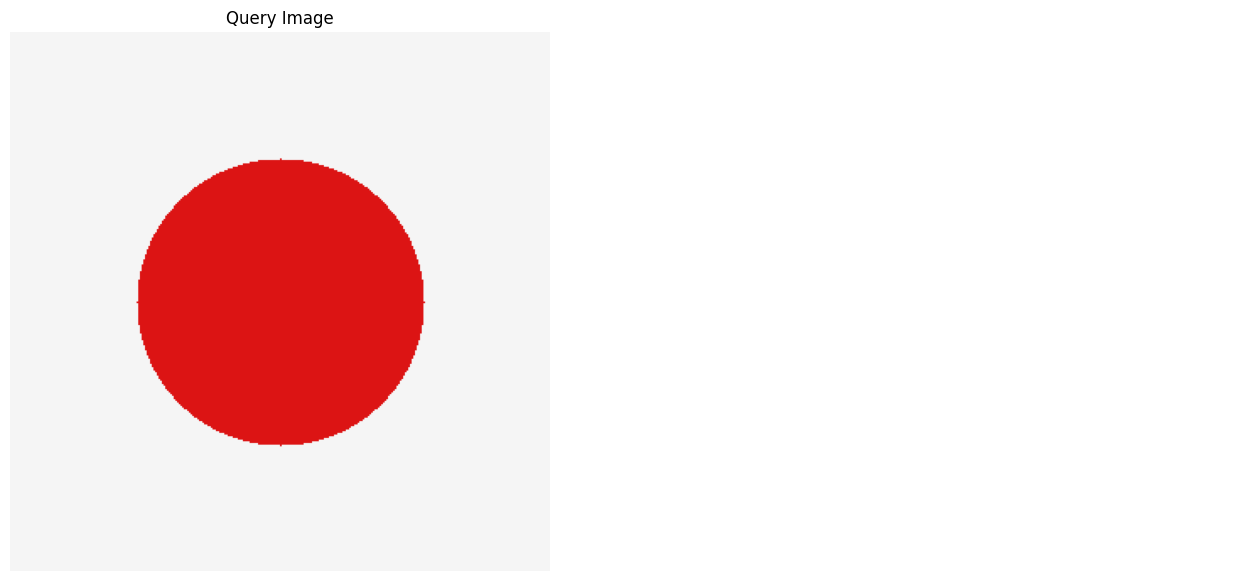

In [27]:
exp10 = '10_experiment'

gallery_folder = DATASET_ROOT / 'similarity_gallery'

gallery_files = sorted([
    p for p in gallery_folder.iterdir()
    if p.suffix.lower() in ['.png', '.jpg', '.jpeg']
    and 'query' not in p.name.lower()
])

query_path = gallery_folder / 'query_circle_red.png'

print('Query:', query_path)
print('Gallery images:')

for path in gallery_files:
    print(path.name)

def feature_vector_for_similarity(image):
    image = cv2.resize(image, (128, 128))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    gray_hist = cv2.calcHist(
        [gray],
        [0],
        None,
        [32],
        [0, 256]
    ).flatten()

    gray_hist = gray_hist / max(gray_hist.sum(), 1)

    color_features = []

    for channel in range(3):
        upper = 180 if channel == 0 else 256

        hist = cv2.calcHist(
            [hsv],
            [channel],
            None,
            [16],
            [0, upper]
        ).flatten()

        hist = hist / max(hist.sum(), 1)
        color_features.extend(hist)

    lbp = local_binary_pattern(
        gray,
        8,
        1,
        method='uniform'
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 11),
        range=(0, 10)
    )

    lbp_hist = lbp_hist.astype(np.float32)
    lbp_hist = lbp_hist / max(lbp_hist.sum(), 1)

    gabor_features = []

    for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
        kernel = cv2.getGaborKernel(
            (31, 31),
            4,
            theta,
            10,
            0.5,
            0,
            ktype=cv2.CV_32F
        )

        response = cv2.filter2D(
            gray.astype(np.float32) / 255,
            cv2.CV_32F,
            kernel
        )

        gabor_features.extend([
            np.mean(response),
            np.std(response),
            np.mean(response ** 2)
        ])

    f = np.fft.fft2(gray.astype(np.float32))
    fshift = np.fft.fftshift(f)
    spectrum = np.log1p(np.abs(fshift))

    h, w = spectrum.shape
    cy = h // 2
    cx = w // 2

    yy, xx = np.indices((h, w))
    radius = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)

    max_radius = min(h, w) / 2

    spectral_features = []

    for r1, r2 in zip(
        np.linspace(0, max_radius, 17)[:-1],
        np.linspace(0, max_radius, 17)[1:]
    ):
        mask = (radius >= r1) & (radius < r2)

        if np.any(mask):
            spectral_features.append(np.mean(spectrum[mask]))
        else:
            spectral_features.append(0)

    return np.concatenate([
        gray_hist,
        np.asarray(color_features),
        lbp_hist,
        np.asarray(gabor_features),
        np.asarray(spectral_features)
    ]).astype(np.float32)

query_image = cv2.imread(str(query_path))

query_vector = feature_vector_for_similarity(query_image)

gallery_vectors = []
gallery_names = []

for path in gallery_files:
    gallery_image = cv2.imread(str(path))
    vector = feature_vector_for_similarity(gallery_image)
    gallery_vectors.append(vector)
    gallery_names.append(path.name)

gallery_vectors = np.asarray(gallery_vectors)

all_vectors = np.vstack([
    query_vector,
    gallery_vectors
])

scaler = StandardScaler()
normalized_vectors = scaler.fit_transform(all_vectors)

normalized_query = normalized_vectors[0]
normalized_gallery = normalized_vectors[1:]

results = []

for name, vector in zip(gallery_names, normalized_gallery):
    euclidean = np.linalg.norm(normalized_query - vector)
    manhattan = np.sum(np.abs(normalized_query - vector))

    query_norm = np.linalg.norm(normalized_query)
    vector_norm = np.linalg.norm(vector)

    cosine = (
        np.dot(normalized_query, vector) /
        max(query_norm * vector_norm, 1e-12)
    )

    if np.std(normalized_query) == 0 or np.std(vector) == 0:
        correlation = 0
    else:
        correlation = np.corrcoef(
            normalized_query,
            vector
        )[0, 1]

    results.append({
        'Image': name,
        'Euclidean_Distance': euclidean,
        'Manhattan_Distance': manhattan,
        'Cosine_Similarity': cosine,
        'Correlation': correlation
    })

results_df = pd.DataFrame(results)

euclidean_rank = results_df.sort_values(
    'Euclidean_Distance',
    ascending=True
).reset_index(drop=True)

manhattan_rank = results_df.sort_values(
    'Manhattan_Distance',
    ascending=True
).reset_index(drop=True)

cosine_rank = results_df.sort_values(
    'Cosine_Similarity',
    ascending=False
).reset_index(drop=True)

correlation_rank = results_df.sort_values(
    'Correlation',
    ascending=False
).reset_index(drop=True)

euclidean_rank['Euclidean_Rank'] = np.arange(1, len(euclidean_rank) + 1)
manhattan_rank['Manhattan_Rank'] = np.arange(1, len(manhattan_rank) + 1)
cosine_rank['Cosine_Rank'] = np.arange(1, len(cosine_rank) + 1)
correlation_rank['Correlation_Rank'] = np.arange(1, len(correlation_rank) + 1)

ranking_df = results_df.copy()

ranking_df['Euclidean_Rank'] = ranking_df[
    'Euclidean_Distance'
].rank(
    ascending=True,
    method='min'
).astype(int)

ranking_df['Manhattan_Rank'] = ranking_df[
    'Manhattan_Distance'
].rank(
    ascending=True,
    method='min'
).astype(int)

ranking_df['Cosine_Rank'] = ranking_df[
    'Cosine_Similarity'
].rank(
    ascending=False,
    method='min'
).astype(int)

ranking_df['Correlation_Rank'] = ranking_df[
    'Correlation'
].rank(
    ascending=False,
    method='min'
).astype(int)

ranking_df['Average_Rank'] = ranking_df[
    [
        'Euclidean_Rank',
        'Manhattan_Rank',
        'Cosine_Rank',
        'Correlation_Rank'
    ]
].mean(axis=1)

ranking_df = ranking_df.sort_values(
    'Average_Rank'
).reset_index(drop=True)

ranking_df['Overall_Rank'] = np.arange(
    1,
    len(ranking_df) + 1
)

ranking_df.to_csv(
    OUTPUT_ROOT / exp10 / 'similarity_ranking.csv',
    index=False
)

np.save(
    OUTPUT_ROOT / exp10 / 'query_feature_vector.npy',
    query_vector
)

np.save(
    OUTPUT_ROOT / exp10 / 'gallery_feature_vectors.npy',
    gallery_vectors
)

display(ranking_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

query_rgb = cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB)

axes[0].imshow(query_rgb)
axes[0].set_title('Query Image')
axes[0].axis('off')

top_images = ranking_df.head(4)

axes[1].axis('off')

fig2, axes2 = plt.subplots(
    1,
    len(top_images),
    figsize=(16, 4)
)

if len(top_images) == 1:
    axes2 = [axes2]

for ax, (_, row) in zip(axes2, top_images.iterrows()):
    img = cv2.imread(
        str(gallery_folder / row['Image'])
    )
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(
        f"Rank {row['Overall_Rank']}\n{row['Image']}"
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig(
    OUTPUT_ROOT / exp10 / 'top_similarity_results.png',
    dpi=200
)
plt.close()

print('Experiment 10 completed')